In [16]:
from music21 import *
import random 
import matplotlib.pyplot as plt
import math
import itertools
import copy

In [17]:
limits = (-7,7)
walk = [0]
for idx in range(85):
    step = random.choices([-3,-2,-1,0,1,2,3], [1,2,3,1,3,2,1])[0]
    walk_value = walk[-1] + step
    print(f"old value: {walk_value}")
    if walk_value < limits[0] or walk_value > limits[1]:
        walk_value -= 2*step 
        print(f"new value: {walk_value}")
    walk.append(walk_value)

old value: 1
old value: 0
old value: -2
old value: -5
old value: -4
old value: -1
old value: -2
old value: -1
old value: -1
old value: -3
old value: -4
old value: -1
old value: -4
old value: -3
old value: -4
old value: -6
old value: -7
old value: -9
new value: -5
old value: -6
old value: -3
old value: -4
old value: -3
old value: -2
old value: 0
old value: 1
old value: 0
old value: -1
old value: 1
old value: 2
old value: 3
old value: 2
old value: 5
old value: 7
old value: 4
old value: 6
old value: 3
old value: 6
old value: 4
old value: 6
old value: 4
old value: 2
old value: 4
old value: 3
old value: 5
old value: 4
old value: 2
old value: 3
old value: 1
old value: 3
old value: 4
old value: 2
old value: 3
old value: 5
old value: 4
old value: 5
old value: 6
old value: 8
new value: 4
old value: 4
old value: 5
old value: 3
old value: 1
old value: -2
old value: -4
old value: -3
old value: -2
old value: 0
old value: 3
old value: 5
old value: 4
old value: 3
old value: 3
old value: 1
old value: 

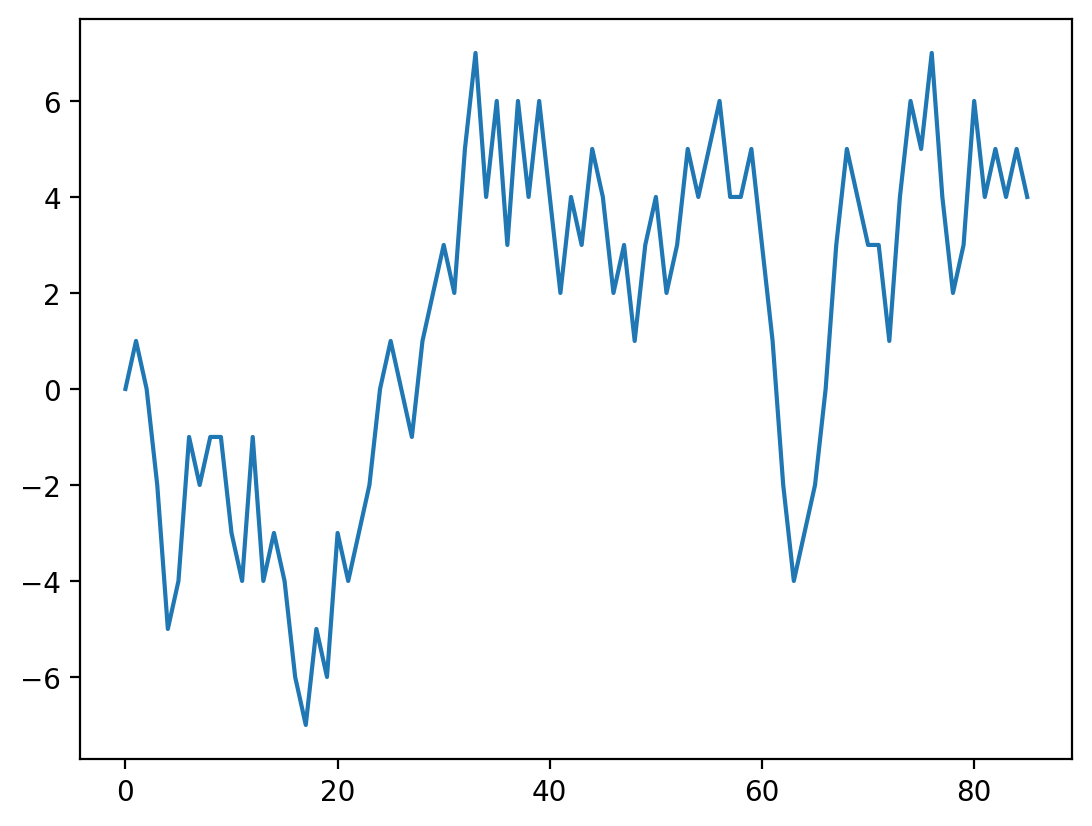

In [18]:
plt.plot(walk)

In [19]:
my_scale = scale.MajorScale("C")
my_stream = stream.Part()
for val in walk:
    my_length = random.choices([1., 2., 0.5, 0.25], [1., 0.5, 2., 0.25])[0]
    if val == 0:
        current_note = note.Note("C5", quarterLength = my_length)
    else:
        current_note = note.Note(my_scale.nextPitch("C5", val),quarterLength = my_length)
    my_stream.append(current_note)

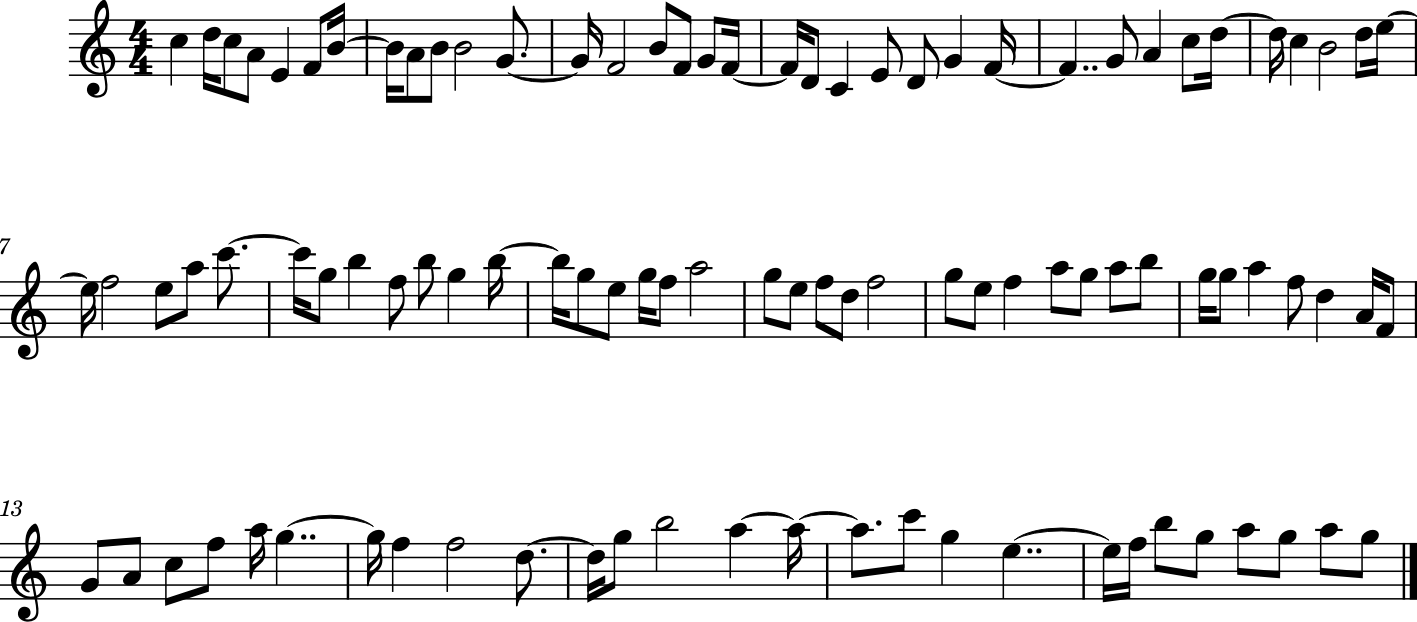

In [20]:
my_stream.show()

In [21]:
my_stream.show("midi")

In [22]:
math.ceil(my_stream.highestTime / 4)

17

In [34]:
my_harmony = stream.Part()
chord_progession = itertools.cycle(["I", "V", "vi", "IV"])
for idx, chord_sym in zip(range(math.ceil(my_stream.highestTime / 4)), chord_progession):
    print(f"index: {idx}, chord: {chord_sym}")
    my_chord = roman.RomanNumeral(chord_sym, key.Key('C'))
    my_chord = my_chord.transpose(-12)
    my_chord.quarterLength = 2.0
    my_chord.volume.velocity = 35
    print(my_chord.pitches)
    fifth_chord = chord.Chord([my_chord.pitches[0], my_chord.pitches[2]])
    fifth_chord.quarterLength = 0.5
    fifth_chord.volume.velocity = 35
    my_harmony.append(fifth_chord)
    my_harmony.append(copy.deepcopy(fifth_chord))
    my_harmony.append(copy.deepcopy(fifth_chord))
    my_harmony.append(copy.deepcopy(fifth_chord))
    my_harmony.append(my_chord)

index: 0, chord: I
(<music21.pitch.Pitch C3>, <music21.pitch.Pitch E3>, <music21.pitch.Pitch G3>)
index: 1, chord: V
(<music21.pitch.Pitch G3>, <music21.pitch.Pitch B3>, <music21.pitch.Pitch D4>)
index: 2, chord: vi
(<music21.pitch.Pitch A3>, <music21.pitch.Pitch C4>, <music21.pitch.Pitch E4>)
index: 3, chord: IV
(<music21.pitch.Pitch F3>, <music21.pitch.Pitch A3>, <music21.pitch.Pitch C4>)
index: 4, chord: I
(<music21.pitch.Pitch C3>, <music21.pitch.Pitch E3>, <music21.pitch.Pitch G3>)
index: 5, chord: V
(<music21.pitch.Pitch G3>, <music21.pitch.Pitch B3>, <music21.pitch.Pitch D4>)
index: 6, chord: vi
(<music21.pitch.Pitch A3>, <music21.pitch.Pitch C4>, <music21.pitch.Pitch E4>)
index: 7, chord: IV
(<music21.pitch.Pitch F3>, <music21.pitch.Pitch A3>, <music21.pitch.Pitch C4>)
index: 8, chord: I
(<music21.pitch.Pitch C3>, <music21.pitch.Pitch E3>, <music21.pitch.Pitch G3>)
index: 9, chord: V
(<music21.pitch.Pitch G3>, <music21.pitch.Pitch B3>, <music21.pitch.Pitch D4>)
index: 10, chord

In [35]:
my_score = stream.Score(id='mainScore')
my_score.insert(0, meter.TimeSignature('4/4'))
my_tempo = tempo.MetronomeMark('slow', number=77)
my_score.insert(0, my_tempo)
my_score.insert(0,my_stream)
my_score.insert(0,my_harmony)

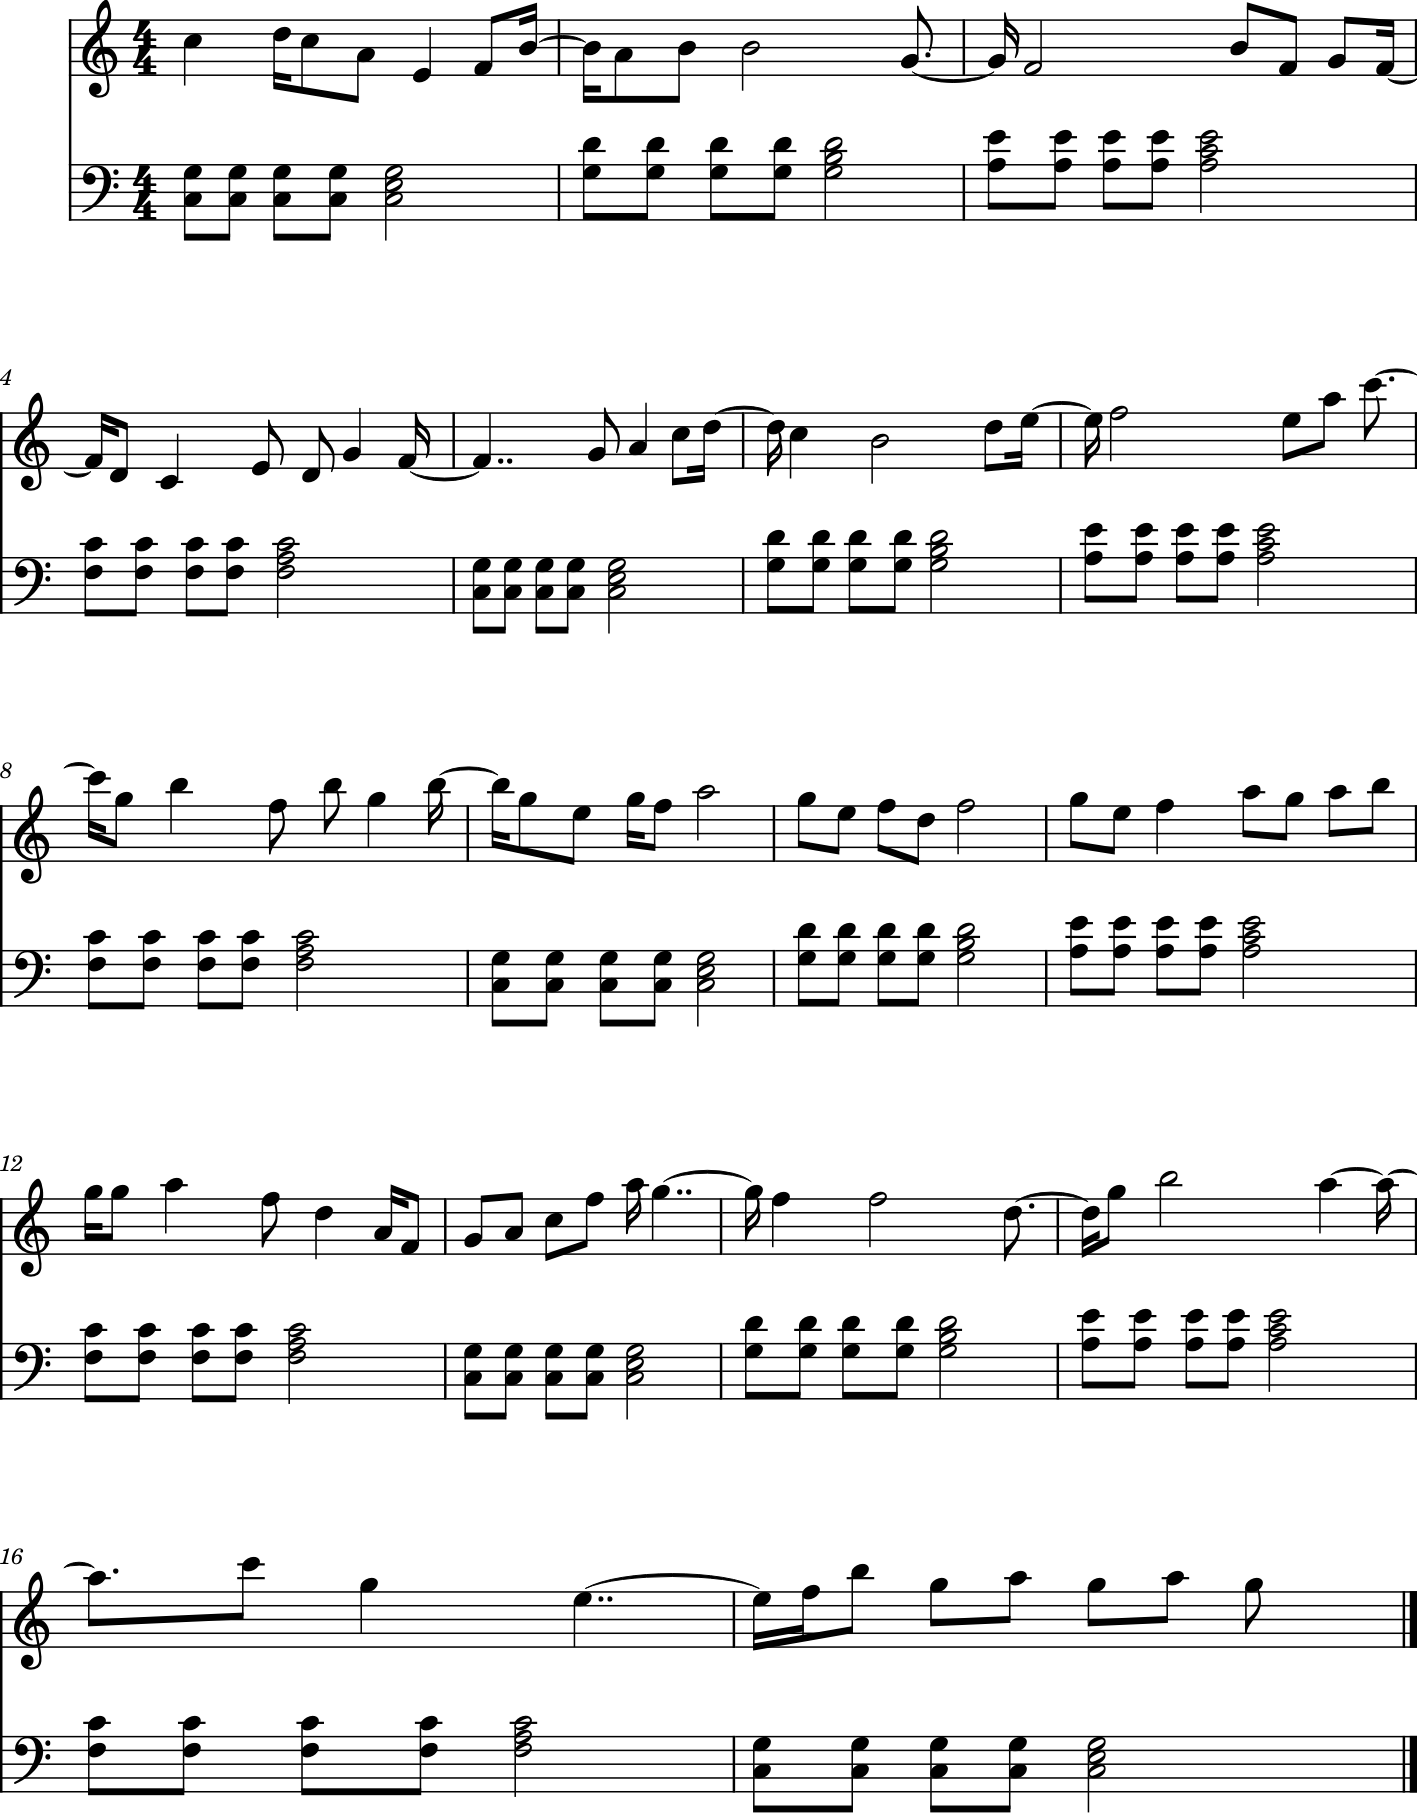

In [36]:
my_score.show()

In [37]:
my_score.show("midi")

In [38]:
my_chord.pitches[0]

<music21.pitch.Pitch C3>

In [15]:
chord.Chord([my_chord.pitches[0], my_chord.pitches[1]])

<music21.chord.Chord G3 B3>

In [42]:
my_score.write("midi", "random_walk.midi")

'random_walk.midi'